# 3장 2강: 피어슨 상관계수의 의미와 한계 — 실습문제

## 실습 목표

- 두 연속형 변수의 피어슨 상관계수와 p-value를 계산하고 방향·강도를 해석합니다.
- 결정계수 $r^2$의 의미를 올바르게 설명합니다.
- 산점도를 함께 확인하여 이상치와 비선형 관계가 피어슨 상관계수에 미치는 영향을 판단합니다.
- 상관관계만으로 인과관계를 주장할 수 없는 이유와 가능한 혼란변수를 설명합니다.

## 실습 환경 / 데이터

- Python, pandas, NumPy, SciPy, Matplotlib
- `ames_housing.csv`
- 주요 변수: `SalePrice`, `GrLivArea`, `LotArea`
- 모든 판단은 유의수준 $\alpha=0.05$를 기준으로 합니다.

## 실습 준비

아래 셀을 실행해 데이터를 불러오고 크기, 결측치, 컬럼을 확인하세요.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

data_candidates = [
    Path("ames_housing.csv"),
    Path("upload/ames_housing.csv"),]
data_path = next((path for path in data_candidates if path.exists()), None)

if data_path is None:
    raise FileNotFoundError("ames_housing CSV 파일을 노트북과 같은 폴더에 넣어주세요.")

df = pd.read_csv(data_path)
alpha = 0.05

print(f"데이터 크기: {df.shape[0]}행, {df.shape[1]}열")
print("전체 결측치 수:", int(df.isna().sum().sum()))
print("컬럼:", df.columns.tolist())
df.head()


데이터 크기: 1460행, 10열
전체 결측치 수: 0
컬럼: ['SalePrice', 'GrLivArea', 'LotArea', 'OverallQual', 'KitchenQual', 'CentralAir', 'HeatingQC', 'PavedDrive', 'Neighborhood', 'YearBuilt']


,SalePrice,GrLivArea,LotArea,OverallQual,KitchenQual,CentralAir,HeatingQC,PavedDrive,Neighborhood,YearBuilt
0,208500,1710,8450,7,Gd,Y,Ex,Y,CollgCr,2003
1,181500,1262,9600,6,TA,Y,Ex,Y,Veenker,1976
2,223500,1786,11250,7,Gd,Y,Ex,Y,CollgCr,2001
3,140000,1717,9550,7,Gd,Y,Gd,Y,Crawfor,1915
4,250000,2198,14260,8,Gd,Y,Ex,Y,NoRidge,2000


---

## 필수 1. 생활면적과 매매가격의 피어슨 상관분석

`GrLivArea`와 `SalePrice`의 선형 관계를 분석하세요.

### 수행 요구사항

1. 두 변수의 결측치를 제거한 분석용 데이터를 만드세요.
2. `stats.pearsonr()`로 피어슨 상관계수 $r$과 p-value를 계산하세요.
3. $r^2$을 계산하세요.
4. 축 이름과 제목이 있는 산점도를 그리세요.
5. 아래 질문에 문장으로 답하세요.

### 질문

- 상관관계의 방향과 강도는 어떠한가요?
- p-value를 기준으로 선형 상관관계가 통계적으로 유의한가요?
- $r^2$은 이 관계에서 무엇을 의미하나요?
- 이 결과만으로 생활면적 증가가 매매가격 상승의 원인이라고 말할 수 있나요?


--------------------------------------------------
표본 수(n): 1460
피어슨 상관계수(r): 0.7086
p-value: 4.518e-223
결정계수(r^2): 0.5021
유의수준(alpha): 0.05
통계적으로 유의한가: True
--------------------------------------------------


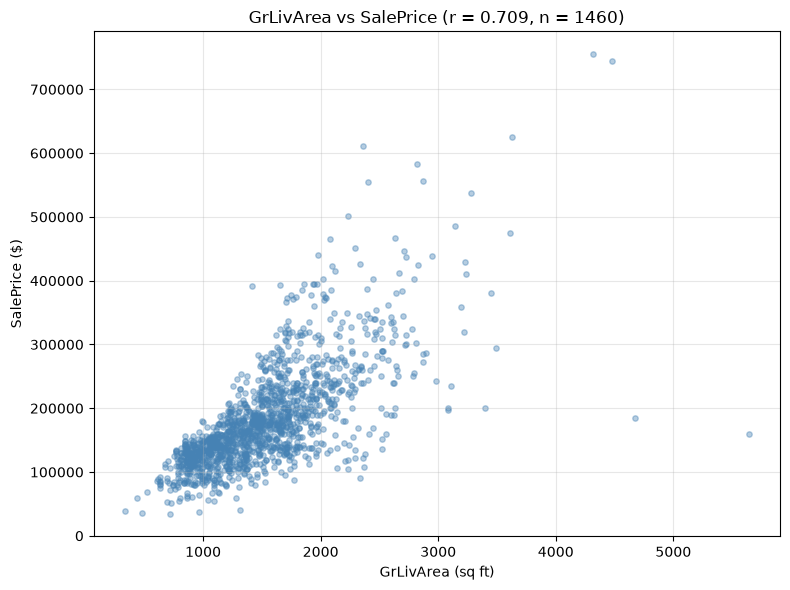

In [2]:
# 여기에 코드를 작성하세요.
area_price = df[['GrLivArea','SalePrice']].dropna()

r_area, p_area = stats.pearsonr(area_price['GrLivArea'], area_price['SalePrice'])
r2_area = r_area ** 2

n = len(area_price)
alpha = 0.05
is_significant = p_area < alpha

print('-' * 50)
print(f'표본 수(n): {n}')
print(f'피어슨 상관계수(r): {r_area:.4f}')
print(f'p-value: {p_area:.4g}')
print(f'결정계수(r^2): {r2_area:.4f}')
print(f'유의수준(alpha): {alpha}')
print(f'통계적으로 유의한가: {is_significant}')
print('-' * 50)

plt.figure(figsize=(8, 6))
plt.scatter(area_price['GrLivArea'], area_price['SalePrice'], alpha=0.4, s=15, color='steelblue')
plt.xlabel('GrLivArea (sq ft)')
plt.ylabel('SalePrice ($)')
plt.title(f'GrLivArea vs SalePrice (r = {r_area:.3f}, n = {n})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('grlivarea_saleprice_scatter.png', dpi=150)


- 상관관계의 방향과 강도는 어떠한가요?
<br> -> r값이 양수값이고 절대값이 0.71이므로 비교적 강한 양의 상관관계

- p-value를 기준으로 선형 상관관계가 통계적으로 유의한가요?
<br> -> p-value가 0.05보다 작으므로 상관계수가 0일 것이라는 귀무가설을 기각한다.
<br> -> 즉 두 변수는 통계적으로 유의하다

- $r^2$은 이 관계에서 무엇을 의미하나요?
<br> -> 같은 자료에 생활면적을 설명변수로 하는 절편을 포함하여 최소제곱 단순 선형회귀를 적합하여 결정계수
<br> -> $r^2$이 약 0.50이다.
<br> -> 즉, 생활면적을 이용한 직선 모형이 이 자료의 가격 변동을 약 50.2% 설명한다.

- 이 결과만으로 생활면적 증가가 매매가격 상승의 원인이라고 말할 수 있나요?
<br> -> 아닙니다. 이미 존재하는 주택의 특성을 관찰한 데이터에서 다른 외부 요인 변수를 분리하여 확인하지 못했다.

---

## 필수 2. 피어슨 상관계수의 두 가지 한계 확인

피어슨 상관계수가 이상치에 민감하고 비선형 관계를 놓칠 수 있다는 점을 확인하세요.

### A. 이상치의 영향

1. `GrLivArea`, `SalePrice`에서 `random_state=42`로 50행을 표본 추출하세요.
2. 표본의 $r$과 p-value를 계산하세요.
3. 학습용 가상 이상치 `(GrLivArea=6000, SalePrice=50000)` 한 행을 표본에만 추가하세요. 원본 `df`는 변경하지 마세요.
4. 이상치 추가 후 $r$과 p-value를 다시 계산하세요.
5. 추가 전후 산점도를 나란히 그리고 결과를 비교하세요.

### B. 비선형 관계

1. `x = [-3, -2, -1, 0, 1, 2, 3]`, `y = x**2`를 만드세요.
2. $x$와 $y$의 $r$과 p-value를 계산하고 산점도를 그리세요.

### 질문

- 이상치 추가 전후 $r$과 유의성 판단은 어떻게 달라졌나요?
- 이 결과는 왜 산점도를 함께 확인해야 함을 보여주나요?
- $y=x^2$는 분명한 관계인데도 $r$이 0에 가까운 이유는 무엇인가요?
- `r ≈ 0`을 “두 변수 사이에 아무 관계도 없다”로 해석해도 되나요?


[이상치 추가 전]
표본 수(n): 50
피어슨 상관계수(r): 0.7059
p-value: 1.026e-08

[이상치 추가 후]
표본 수(n): 51
피어슨 상관계수(r): 0.2602
p-value: 0.06514

[비선형 관계: y = x^2]
피어슨 상관계수(r): 0.0000
p-value: 1


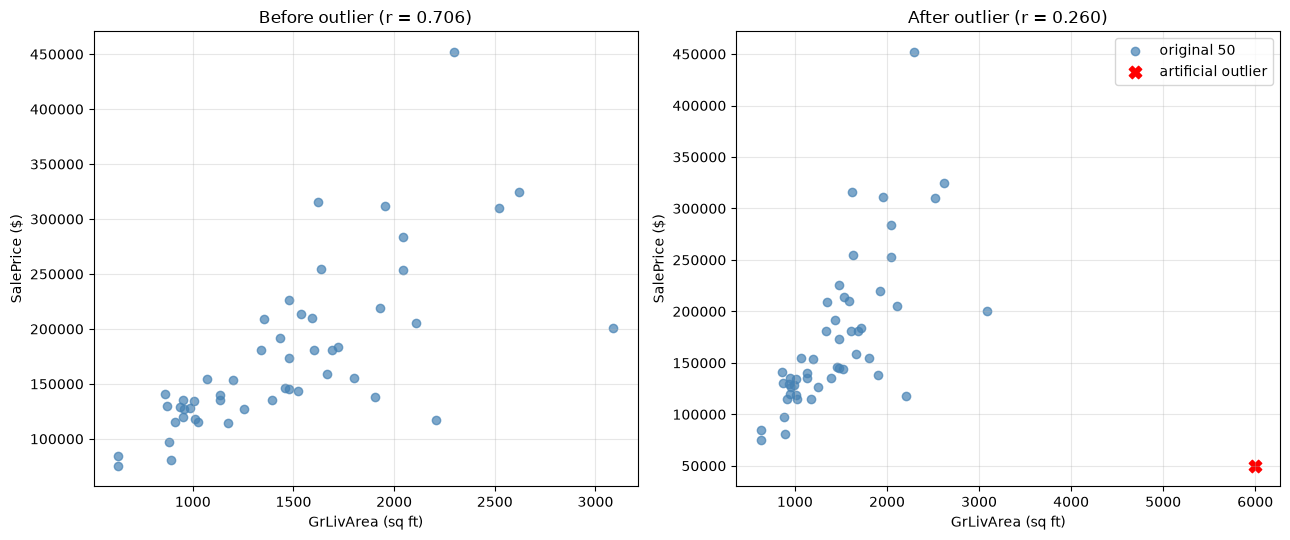

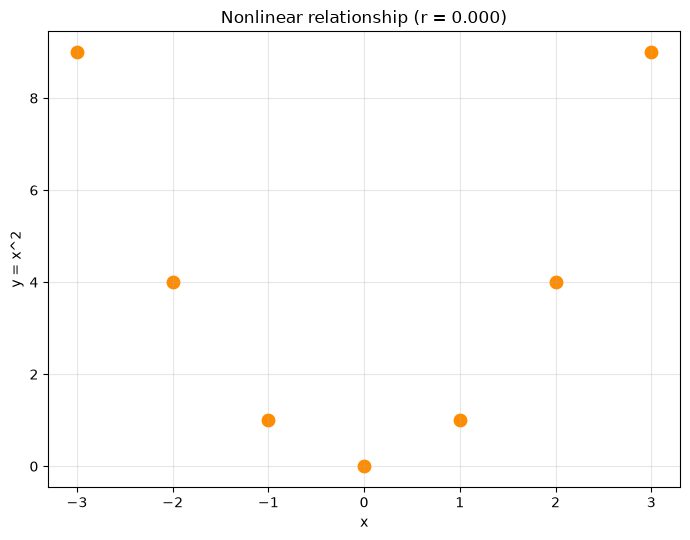

In [3]:
# 여기에 코드를 작성하세요.
# 1. 50행 무작위 표본 추출
sample_50 = df[['GrLivArea','SalePrice']].sample(50, random_state=42).copy()

# 2. 이상치 추가 전 r, p-value
r_before, p_before = stats.pearsonr(sample_50['GrLivArea'], sample_50['SalePrice'])

# 3. 가상 이상치 한 행 추가 (원본 df는 건드리지 않음)
artificial_outlier = pd.DataFrame({'GrLivArea': [6000], 'SalePrice': [50000]})
sample_with_outlier = pd.concat([sample_50, artificial_outlier], ignore_index=True)

# 4. 이상치 추가 후 r, p-value
r_after, p_after = stats.pearsonr(sample_with_outlier['GrLivArea'], sample_with_outlier['SalePrice'])

print('[이상치 추가 전]')
print(f'표본 수(n): {len(sample_50)}')
print(f'피어슨 상관계수(r): {r_before:.4f}')
print(f'p-value: {p_before:.4g}')
print()
print('[이상치 추가 후]')
print(f'표본 수(n): {len(sample_with_outlier)}')
print(f'피어슨 상관계수(r): {r_after:.4f}')
print(f'p-value: {p_after:.4g}')

# 5. 추가 전후 산점도 나란히 그리기
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

axes[0].scatter(sample_50['GrLivArea'], sample_50['SalePrice'], alpha=0.7, color='steelblue')
axes[0].set_xlabel('GrLivArea (sq ft)')
axes[0].set_ylabel('SalePrice ($)')
axes[0].set_title(f'Before outlier (r = {r_before:.3f})')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(sample_50['GrLivArea'], sample_50['SalePrice'], alpha=0.7, color='steelblue', label='original 50')
axes[1].scatter(artificial_outlier['GrLivArea'], artificial_outlier['SalePrice'], color='red', s=80, marker='X', label='artificial outlier')
axes[1].set_xlabel('GrLivArea (sq ft)')
axes[1].set_ylabel('SalePrice ($)')
axes[1].set_title(f'After outlier (r = {r_after:.3f})')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig('outlier_effect_scatter.png', dpi=150)

# ===================================================
# B. 비선형 관계
# ===================================================

# 1. x, y 생성 (완벽한 U자형 곡선 관계: y = x^2)
x = np.array([-3, -2, -1, 0, 1, 2, 3])
y = x ** 2

# 2. r, p-value 계산
r_nonlinear, p_nonlinear = stats.pearsonr(x, y)

print()
print('[비선형 관계: y = x^2]')
print(f'피어슨 상관계수(r): {r_nonlinear:.4f}')
print(f'p-value: {p_nonlinear:.4g}')

# 산점도
plt.figure(figsize=(7, 5.5))
plt.scatter(x, y, s=80, color='darkorange')
plt.xlabel('x')
plt.ylabel('y = x^2')
plt.title(f'Nonlinear relationship (r = {r_nonlinear:.3f})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nonlinear_scatter.png', dpi=150)

- 이상치 추가 전후 $r$과 유의성 판단은 어떻게 달라졌나요?
<br> -> r 0.71 -> 0.26으로 감소, p-value는 0.05미만에서 0.06으로 증가했다.
<br> -> 귀무가설을 기각함에서 귀무가설을 기각할 수 없음으로 판단이 변경

- 이 결과는 왜 산점도를 함께 확인해야 함을 보여주나요?
<br> -> 요약값만 보면 변화의 원인을 한 눈에 파악하기 어려움
<br> -> 산점도는 멀리 떨어진 점들과 일부 선형관계를 한 눈에 파악하기 쉬움
<br> -> 이 점은 이상치도 한 눈에 파악하기 쉽다는 것을 알려줌 

- $y=x^2$는 분명한 관계인데도 $r$이 0에 가까운 이유는 무엇인가요?
<br> -> 피어슨 r은 직선형태의 관계를 요약함
<br> -> u자형 그래프의 왼쪽과 오른쪽은 서로 반대방향의 선형 움직임을 보이기 때문에 0에 가까움

- `r ≈ 0`을 “두 변수 사이에 아무 관계도 없다”로 해석해도 되나요?
<br> -> 아닙니다. r = 0은 선형관계가 거의 없다는 뜻, 비선형 관계는 존재할 수 있다.

---

## 과제. 대지면적과 매매가격의 관계를 근거 있게 보고하기

`LotArea`와 `SalePrice`의 관계를 분석하고, 상관과 인과를 구별한 짧은 분석 보고를 작성하세요.

### 수행 요구사항

1. 두 변수의 피어슨 상관계수, p-value, $r^2$을 계산하세요.
2. 산점도를 그려 관계의 형태와 이상치 여부를 확인하세요.
3. 유의수준 0.05에서 통계적 유의성을 판단하세요.
4. 아래 질문에 빠짐없이 답하는 5~7문장의 결론을 작성하세요.

### 질문

- 관계의 방향과 강도는 어떠한가요?
- 통계적으로 유의한 결과와 강한 관계는 같은 의미인가요?
- 대지면적이 넓어지면 매매가격이 오른다는 인과결론을 내릴 수 있나요?
- 두 변수에 함께 영향을 줄 수 있는 혼란변수를 두 가지 이상 제시하세요.
- 피어슨 상관계수가 0에 가까우면 두 변수 사이에 아무 관계도 없다고 판단해도 되나요? U자형 관계를 예로 들어 설명하세요.

피어슨 상관계수(r): 0.3759
p-value: 7.1459e-03
$r^2$: 0.1413


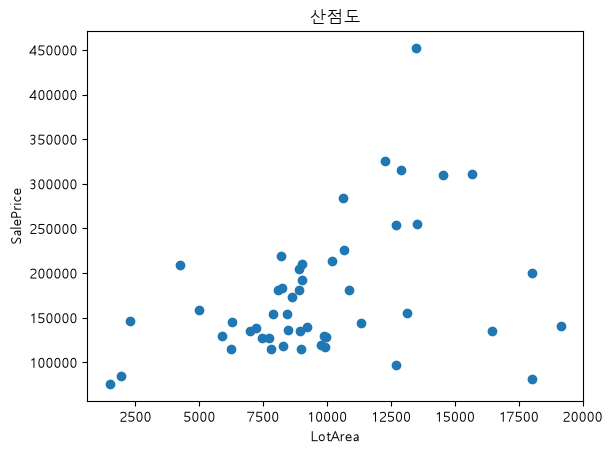

귀무가설을 기각합니다. 두 변수는 통계적으로 유의한 상관관계가 있습니다.


In [9]:
# 여기에 코드를 작성하세요.
plt.rcParams['font.family'] = 'Malgun Gothic'
# 1. 50행 무작위 표본 추출
sample_50 = df[['LotArea','SalePrice']].sample(50, random_state=42).copy()

# 1. 두 변수의 피어슨 상관계수, p-value, $r^2$을 계산하세요.
corr, p_value = stats.pearsonr(sample_50['LotArea'], sample_50['SalePrice'])
r_squared = corr ** 2

print(f'피어슨 상관계수(r): {corr:.4f}')
print(f'p-value: {p_value:.4e}')
print(f'$r^2$: {r_squared:.4f}')

# 2. 산점도를 그려 관계의 형태와 이상치 여부를 확인하세요.
plt.scatter(sample_50['LotArea'], sample_50['SalePrice'])
plt.xlabel('LotArea')
plt.ylabel('SalePrice')
plt.title('산점도')
plt.show()

# 3. 유의수준 0.05에서 통계적 유의성을 판단하세요.
alpha = 0.05
if p_value < alpha:
    print("귀무가설을 기각합니다. 두 변수는 통계적으로 유의한 상관관계가 있습니다.")
else:
    print("귀무가설을 기각하지 못합니다.") 

#

- 관계의 방향과 강도는 어떠한가요?
- 통계적으로 유의한 결과와 강한 관계는 같은 의미인가요?
- 대지면적이 넓어지면 매매가격이 오른다는 인과결론을 내릴 수 있나요?
- 두 변수에 함께 영향을 줄 수 있는 혼란변수를 두 가지 이상 제시하세요.
- 피어슨 상관계수가 0에 가까우면 두 변수 사이에 아무 관계도 없다고 판단해도 되나요? U자형 관계를 예로 들어 설명하세요.

-------------------------------------------------------------------------
[결론]
p-value 7.1459e-03 로 두 변수 사이에는 상관관계가 있다고 볼 만한 통계적 유의미한 결과가 있다. 
두 변수의 피어슨 상관계수는 0.3759로 양의 상관관계를 가지고 있으며 강도는 약한 상관관계를 가지고 있다.
통계적으로 유의한 결과는 관계가 존재하는지를 판단하는 것이고 강도는 얼마나 강한 관계가 있는가를 묻는 것으로 같은 의미가 아니다.
두 변수 사이의 상관 관계가 있다는 것이 인과관계라는 결론을 내릴 수 없다. 두 변수에 영향을 줄 수 있는 GrLivArea, Neighborhood와 같은 혼란변수가 있기 때문이다. 피어슨 상관계수가 0에 가깝다고 해서 두 변수 사이에 아무런 관계도 없다고 판단해서는 안 된다. 피어슨 상관계수는 직선 형태의 관계를 나타내는 지표로 U자형 관계(ex.y=x²)에서는 값이 상쇄되어 상관계수가 0에 가깝게 나오지만 두 관계 사이에는 비선형 관계가 존재한다. 따라서 이 경우에는 산점도를 통해 비선형 패턴이 있는지 확인이 필요하다.

---

## 실습 마무리

- 어떤 문제가 있었는가?
<br> -> 상관계수와 p-value만으로는 관계를 명확하게 규정하기 어려움

- 어떻게 개선했는가?
<br> -> r, %r^2%, p-value, 산점도, 이상치 유/무, 

- 무엇을 근거로 개선되었다고 판단했는가?
<br> -> 이상치 값 하나로 r값과 p-value가 달라지는 것을 확인했다.
<br> -> 본 데이터의 이상치를 제거한다면 정상적인 r값과 p-value로 올바른 통계적 해석이 가능하다.

피어슨 상관계수의 숫자만 보았을 때 놓칠 수 있었던 점, 산점도와 인과적 관점을 추가해 해석이 어떻게 개선되었는지 정리하세요.